In [1]:
from google.colab import files

uploaded = files.upload()

Saving Base.csv.zip to Base.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile("Base.csv.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Extraction complete!")

Extraction complete!


In [3]:
import os

print(os.listdir("/content"))

['.config', 'Base.csv.zip', 'Base.csv', 'sample_data']


In [4]:
import pandas as pd

df = pd.read_csv("/content/Base.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000000, 32)


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Information:")
df.info()

Dataset Shape:
(1000000, 32)

First 5 rows:


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h     

In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                            

In [7]:
print("Fraud distribution:")
print(df["fraud_bool"].value_counts())

print("\nFraud percentage:")
print(df["fraud_bool"].value_counts(normalize=True) * 100)

Fraud distribution:
fraud_bool
0    988971
1     11029
Name: count, dtype: int64

Fraud percentage:
fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64


In [8]:
print("Unique values in each column:\n")

for col in df.columns:
    print(f"{col:35} {df[col].nunique()}")

Unique values in each column:

fraud_bool                          2
income                              9
name_email_similarity               998861
prev_address_months_count           374
current_address_months_count        423
customer_age                        9
days_since_request                  989330
intended_balcon_amount              994971
payment_type                        5
zip_count_4w                        6306
velocity_6h                         998687
velocity_24h                        998940
velocity_4w                         998318
bank_branch_count_8w                2326
date_of_birth_distinct_emails_4w    40
employment_status                   7
credit_risk_score                   551
email_is_free                       2
housing_status                      7
phone_home_valid                    2
phone_mobile_valid                  2
bank_months_count                   33
has_other_cards                     2
proposed_credit_limit               12
foreign_requ

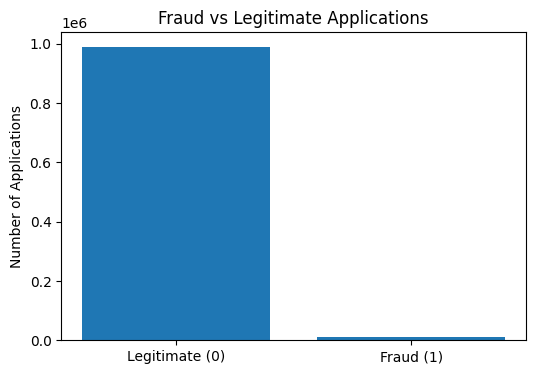

In [9]:
import matplotlib.pyplot as plt

counts = df["fraud_bool"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Legitimate (0)", "Fraud (1)"], counts.values)

plt.title("Fraud vs Legitimate Applications")
plt.ylabel("Number of Applications")

plt.show()

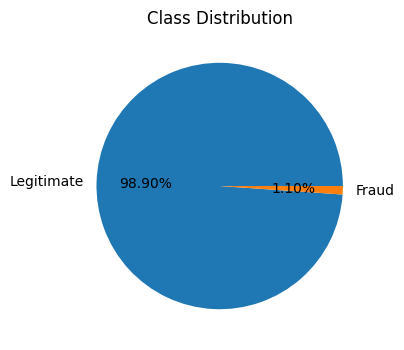

In [10]:
plt.figure(figsize=(6, 4))

plt.pie(
    counts.values,
    labels=["Legitimate", "Fraud"],
    autopct="%.2f%%"
)

plt.title("Class Distribution")
plt.show()

In [11]:
# Display basic statistical information
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [12]:
# Find columns containing categorical/text data

categorical_columns = df.select_dtypes(include=["object", "category"]).columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nNumber of categorical columns:", len(categorical_columns))

Categorical columns:
['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

Number of categorical columns: 5


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
for col in df.columns:
    count = (df[col] == -1).sum()

    if count > 0:
        print(f"{col:40} {count}")

prev_address_months_count                712920
current_address_months_count             4254
credit_risk_score                        488
bank_months_count                        253635
session_length_in_minutes                2015
device_distinct_emails_8w                359


In [15]:
# Compare numerical features for legitimate vs fraudulent applications

numerical_columns = df.select_dtypes(include=["number"]).columns
comparison = df.groupby("fraud_bool")[numerical_columns].mean().T
comparison.columns = ["Legitimate", "Fraud"]
comparison["Difference"] = (
    comparison["Fraud"] - comparison["Legitimate"]
)

display(comparison.sort_values("Difference", ascending=False))

,Legitimate,Fraud,Difference
proposed_credit_limit,512.303162,833.986762,321.683601
zip_count_4w,1572.138693,1622.311542,50.172850
credit_risk_score,130.469904,177.590353,47.120449
current_address_months_count,86.273232,114.801161,28.527928
customer_age,33.609125,40.858645,7.249520
fraud_bool,0.000000,1.000000,1.000000
session_length_in_minutes,7.537306,8.229520,0.692214
month,3.285582,3.565962,0.280381
email_is_free,0.528423,0.661075,0.132652
income,0.561313,0.686635,0.125322


In [16]:
categorical_columns = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]

for col in categorical_columns:
    print(f"\n===== {col} =====")

    fraud_rate = df.groupby(col)["fraud_bool"].mean() * 100

    print(fraud_rate.sort_values(ascending=False))


===== payment_type =====
payment_type
AC    1.669768
AB    1.125072
AD    1.082155
AA    0.528172
AE    0.346021
Name: fraud_bool, dtype: float64

===== employment_status =====
employment_status
CC    2.468351
CG    1.545254
CA    1.218620
CB    0.689142
CD    0.377045
CE    0.233552
CF    0.193033
Name: fraud_bool, dtype: float64

===== housing_status =====
housing_status
BA    3.746574
BD    0.863881
BC    0.614817
BB    0.600847
BF    0.419413
BG    0.396825
BE    0.344104
Name: fraud_bool, dtype: float64

===== source =====
source
TELEAPP     1.589103
INTERNET    1.099449
Name: fraud_bool, dtype: float64

===== device_os =====
device_os
windows      2.469393
macintosh    1.397094
x11          1.120642
other        0.575967
linux        0.515461
Name: fraud_bool, dtype: float64


In [17]:
# Target variable
y = df["fraud_bool"]

# Input features
X = df.drop("fraud_bool", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000000, 31)
y shape: (1000000,)


In [18]:
#data cleaning (to check unique values (no info))
unique_counts = df.nunique().sort_values()
print(unique_counts)

device_fraud_count                       1
fraud_bool                               2
keep_alive_session                       2
foreign_request                          2
phone_home_valid                         2
has_other_cards                          2
email_is_free                            2
source                                   2
phone_mobile_valid                       2
device_distinct_emails_8w                4
device_os                                5
payment_type                             5
employment_status                        7
housing_status                           7
month                                    8
income                                   9
customer_age                             9
proposed_credit_limit                   12
bank_months_count                       33
date_of_birth_distinct_emails_4w        40
prev_address_months_count              374
current_address_months_count           423
credit_risk_score                      551
bank_branch

In [19]:
#removing columns
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("Columns being removed:")
print(constant_columns)

df_clean = df.drop(columns=constant_columns)

print("\nOriginal shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Columns being removed:
['device_fraud_count']

Original shape: (1000000, 32)
Cleaned shape: (1000000, 31)


In [20]:
# Check how dominant the most common value is in each column

for col in df_clean.columns:
    most_common_percentage = df_clean[col].value_counts(normalize=True).iloc[0] * 100

    if most_common_percentage > 99:
        print(f"{col:35} {most_common_percentage:.2f}%")

source                              99.30%


In [21]:
print(df_clean["source"].value_counts())
print("\nPercentage:")
print(df_clean["source"].value_counts(normalize=True) * 100)

source
INTERNET    992952
TELEAPP       7048
Name: count, dtype: int64

Percentage:
source
INTERNET    99.2952
TELEAPP      0.7048
Name: proportion, dtype: float64


In [22]:
for col in df_clean.columns:
    count = (df_clean[col] == -1).sum()

    if count > 0:
        percentage = (count / len(df_clean)) * 100
        print(f"{col:40} {count:10} ({percentage:.2f}%)")

prev_address_months_count                    712920 (71.29%)
current_address_months_count                   4254 (0.43%)
credit_risk_score                               488 (0.05%)
bank_months_count                            253635 (25.36%)
session_length_in_minutes                      2015 (0.20%)
device_distinct_emails_8w                       359 (0.04%)


In [23]:
# Columns where -1 represents missing/unavailable information
import numpy as np
missing_value_columns = [
    "prev_address_months_count",
    "current_address_months_count",
    "credit_risk_score",
    "bank_months_count",
    "session_length_in_minutes",
    "device_distinct_emails_8w"
]
for col in missing_value_columns:
    df_clean[col + "_missing"] = (df_clean[col] == -1).astype(int)

df_clean[missing_value_columns] = df_clean[missing_value_columns].replace(-1, np.nan)

print("Missing-value handling completed!")
print("New shape:", df_clean.shape)

Missing-value handling completed!
New shape: (1000000, 37)


In [24]:
from sklearn.model_selection import train_test_split

y = df_clean["fraud_bool"]
X = df_clean.drop("fraud_bool", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (800000, 36)
X_test: (200000, 36)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [26]:

categorical_columns = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]
numerical_columns = [
    col for col in X_train.columns
    if col not in categorical_columns
]
numeric_transformer = SimpleImputer(
    strategy="median"
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Numerical columns:", len(numerical_columns))
print("Categorical columns:", len(categorical_columns))
print("\nPreprocessor created successfully!")

Numerical columns: 31
Categorical columns: 5

Preprocessor created successfully!


In [27]:
# Fit the preprocessor ONLY on the training data
preprocessor.fit(X_train)

# Transform training and testing data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (800000, 36)
Processed training shape: (800000, 57)

Original testing shape: (200000, 36)
Processed testing shape: (200000, 57)


In [28]:
import numpy as np
import pandas as pd

for col in numerical_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Data types fixed!")

print("\nMissing values:")
print(df_clean[numerical_columns].isna().sum().sort_values(ascending=False).head(10))

Data types fixed!

Missing values:
prev_address_months_count       712920
bank_months_count               253635
current_address_months_count      4254
session_length_in_minutes         2015
credit_risk_score                  488
device_distinct_emails_8w          359
name_email_similarity                0
intended_balcon_amount               0
zip_count_4w                         0
velocity_24h                         0
dtype: int64


In [29]:
from sklearn.model_selection import train_test_split

y = df_clean["fraud_bool"]
X = df_clean.drop("fraud_bool", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (800000, 36)
X_test: (200000, 36)


In [30]:
# Fit the preprocessor only on the training data
preprocessor.fit(X_train)

# Transform both datasets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (800000, 36)
Processed training shape: (800000, 57)

Original testing shape: (200000, 36)
Processed testing shape: (200000, 57)


In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [32]:
# Make predictions on the test data
y_pred = dt_model.predict(X_test_processed)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 200000


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("===== Decision Tree Performance =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

print("\n===== Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred))

===== Decision Tree Performance =====
Accuracy : 0.9770
Precision: 0.0742
Recall   : 0.0947
F1 Score : 0.0833
ROC-AUC  : 0.5408

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    197794
           1       0.07      0.09      0.08      2206

    accuracy                           0.98    200000
   macro avg       0.53      0.54      0.54    200000
weighted avg       0.98      0.98      0.98    200000


===== Confusion Matrix =====
[[195188   2606]
 [  1997    209]]


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions on training data
y_train_pred = dt_model.predict(X_train_processed)

print("===== TRAINING PERFORMANCE =====")

print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred):.4f}")
print(f"F1 Score : {f1_score(y_train, y_train_pred):.4f}")

===== TRAINING PERFORMANCE =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [35]:
#checking with different depths
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Decision Tree with limited depth
dt_depth5 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Train
dt_depth5.fit(X_train_processed, y_train)

# Predictions
y_train_pred_depth5 = dt_depth5.predict(X_train_processed)
y_test_pred_depth5 = dt_depth5.predict(X_test_processed)

# Metrics
print("===== MAX DEPTH = 5 =====")

print("\nTraining:")
print("Precision:", round(precision_score(y_train, y_train_pred_depth5), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred_depth5), 4))
print("F1 Score :", round(f1_score(y_train, y_train_pred_depth5), 4))

print("\nTesting:")
print("Precision:", round(precision_score(y_test, y_test_pred_depth5), 4))
print("Recall   :", round(recall_score(y_test, y_test_pred_depth5), 4))
print("F1 Score :", round(f1_score(y_test, y_test_pred_depth5), 4))

===== MAX DEPTH = 5 =====

Training:
Precision: 0.5694
Recall   : 0.0046
F1 Score : 0.0092

Testing:
Precision: 0.5294
Recall   : 0.0041
F1 Score : 0.0081


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Test depths from 1 to 100
depths = list(range(1, 50, 5))

results = []

for depth in depths:

    print(f"Training max_depth = {depth}...")

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_processed, y_train)

    # Predictions
    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    # Store results
    results.append({
        "max_depth": depth,

        "train_precision": precision_score(
            y_train, train_pred, zero_division=0
        ),

        "train_recall": recall_score(
            y_train, train_pred, zero_division=0
        ),

        "train_f1": f1_score(
            y_train, train_pred, zero_division=0
        ),

        "test_precision": precision_score(
            y_test, test_pred, zero_division=0
        ),

        "test_recall": recall_score(
            y_test, test_pred, zero_division=0
        ),

        "test_f1": f1_score(
            y_test, test_pred, zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

Training max_depth = 1...
Training max_depth = 6...
Training max_depth = 11...
Training max_depth = 16...
Training max_depth = 21...
Training max_depth = 26...
Training max_depth = 31...
Training max_depth = 36...
Training max_depth = 41...
Training max_depth = 46...


,max_depth,train_precision,train_recall,train_f1,test_precision,test_recall,test_f1
0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6,0.653226,0.009181,0.018107,0.458333,0.004986,0.009865
2,11,0.861139,0.097699,0.175489,0.201493,0.024479,0.043654
3,16,0.967720,0.319392,0.480273,0.130588,0.050317,0.072644
4,21,0.989267,0.605916,0.751529,0.100733,0.074796,0.085848
5,26,0.996212,0.834637,0.908295,0.084973,0.086129,0.085547
6,31,0.997749,0.954324,0.975553,0.078210,0.091115,0.084171
7,36,1.000000,0.994106,0.997044,0.077036,0.094742,0.084977
8,41,1.000000,0.999547,0.999773,0.074753,0.092475,0.082675
9,46,1.000000,1.000000,1.000000,0.074245,0.094742,0.083250


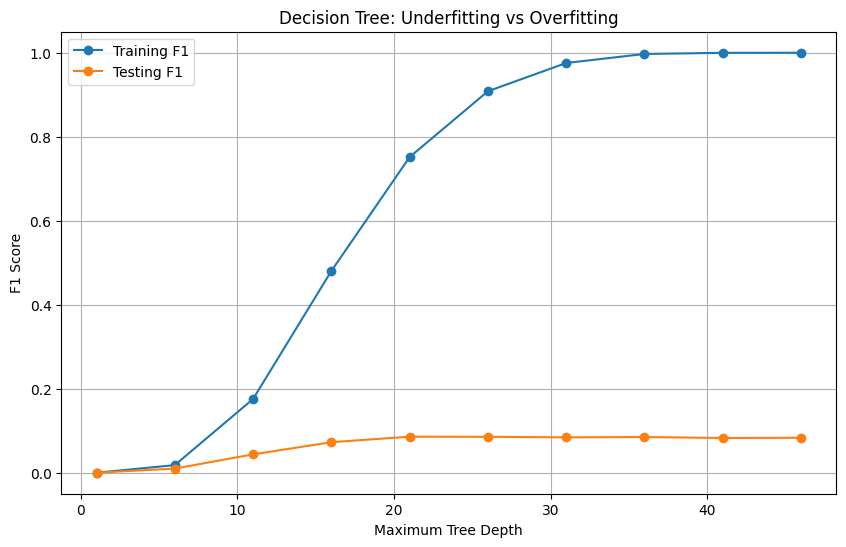

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    results_df["max_depth"],
    results_df["train_f1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    results_df["max_depth"],
    results_df["test_f1"],
    marker="o",
    label="Testing F1"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("F1 Score")
plt.title("Decision Tree: Underfitting vs Overfitting")
plt.legend()
plt.grid(True)

plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

criteria = ["gini", "entropy"]

criterion_results = []

for criterion in criteria:

    print(f"Training with criterion = {criterion}...")

    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=21,
        random_state=42
    )

    model.fit(X_train_processed, y_train)

    # Predictions
    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    criterion_results.append({
        "criterion": criterion,

        "train_precision": precision_score(
            y_train, train_pred, zero_division=0
        ),

        "train_recall": recall_score(
            y_train, train_pred, zero_division=0
        ),

        "train_f1": f1_score(
            y_train, train_pred, zero_division=0
        ),

        "test_precision": precision_score(
            y_test, test_pred, zero_division=0
        ),

        "test_recall": recall_score(
            y_test, test_pred, zero_division=0
        ),

        "test_f1": f1_score(
            y_test, test_pred, zero_division=0
        )
    })

criterion_results_df = pd.DataFrame(criterion_results)

display(criterion_results_df)

Training with criterion = gini...
Training with criterion = entropy...


,criterion,train_precision,train_recall,train_f1,test_precision,test_recall,test_f1
0,gini,0.989267,0.605916,0.751529,0.100733,0.074796,0.085848
1,entropy,0.978417,0.755299,0.852501,0.090531,0.078876,0.084302


In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Normal": DecisionTreeClassifier(
        criterion="gini",
        max_depth=21,
        class_weight=None,
        random_state=42
    ),

    "Balanced": DecisionTreeClassifier(
        criterion="gini",
        max_depth=21,
        class_weight="balanced",
        random_state=42
    )
}

class_weight_results = []

for name, model in models.items():

    print(f"Training: {name}")

    model.fit(X_train_processed, y_train)

    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    class_weight_results.append({
        "model": name,

        "train_precision": precision_score(
            y_train, train_pred, zero_division=0
        ),

        "train_recall": recall_score(
            y_train, train_pred, zero_division=0
        ),

        "train_f1": f1_score(
            y_train, train_pred, zero_division=0
        ),

        "test_precision": precision_score(
            y_test, test_pred, zero_division=0
        ),

        "test_recall": recall_score(
            y_test, test_pred, zero_division=0
        ),

        "test_f1": f1_score(
            y_test, test_pred, zero_division=0
        )
    })

class_weight_results_df = pd.DataFrame(class_weight_results)

display(class_weight_results_df)


Training: Normal
Training: Balanced


,model,train_precision,train_recall,train_f1,test_precision,test_recall,test_f1
0,Normal,0.989267,0.605916,0.751529,0.100733,0.074796,0.085848
1,Balanced,0.139145,0.998980,0.244267,0.057071,0.408885,0.100161


In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

depths = [3, 5, 10, 15, 20, 25, 30, 35, 40]

balanced_results = []

for depth in depths:

    print(f"Training max_depth = {depth}...")

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_processed, y_train)

    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    balanced_results.append({
        "max_depth": depth,

        "train_precision": precision_score(
            y_train, train_pred, zero_division=0
        ),
        "train_recall": recall_score(
            y_train, train_pred, zero_division=0
        ),
        "train_f1": f1_score(
            y_train, train_pred, zero_division=0
        ),

        "test_precision": precision_score(
            y_test, test_pred, zero_division=0
        ),
        "test_recall": recall_score(
            y_test, test_pred, zero_division=0
        ),
        "test_f1": f1_score(
            y_test, test_pred, zero_division=0
        )
    })

balanced_results_df = pd.DataFrame(balanced_results)

display(balanced_results_df)

Training max_depth = 3...
Training max_depth = 5...
Training max_depth = 10...
Training max_depth = 15...
Training max_depth = 20...
Training max_depth = 25...
Training max_depth = 30...
Training max_depth = 35...
Training max_depth = 40...


,max_depth,train_precision,train_recall,train_f1,test_precision,test_recall,test_f1
0,3,0.029573,0.759266,0.056928,0.029756,0.760199,0.057270
1,5,0.039046,0.712569,0.074036,0.039116,0.709429,0.074144
2,10,0.045314,0.848804,0.086034,0.037813,0.706256,0.071782
3,15,0.071130,0.957611,0.132424,0.042392,0.569356,0.078909
4,20,0.124857,0.998753,0.221965,0.054441,0.434270,0.096753
5,25,0.193461,1.000000,0.324202,0.066243,0.344968,0.111144
6,30,0.269363,1.000000,0.424407,0.072795,0.274252,0.115052
7,35,0.361154,1.000000,0.530659,0.077693,0.218042,0.114565
8,40,0.484275,1.000000,0.652540,0.080224,0.168631,0.108724


In [41]:
best_dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

best_dt.fit(X_train_processed, y_train)

y_test_proba = best_dt.predict_proba(X_test_processed)[:, 1]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:

    y_threshold_pred = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, y_threshold_pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_threshold_pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_threshold_pred, zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,threshold,precision,recall,f1
0,0.1,0.014180,0.978694,0.027954
1,0.2,0.014694,0.970082,0.028949
2,0.3,0.022200,0.874433,0.043302
3,0.4,0.026585,0.808250,0.051477
4,0.5,0.039116,0.709429,0.074144
5,0.6,0.047316,0.636446,0.088083
6,0.7,0.050240,0.607434,0.092804
7,0.8,0.087931,0.346782,0.140290
8,0.9,0.114642,0.220762,0.150914


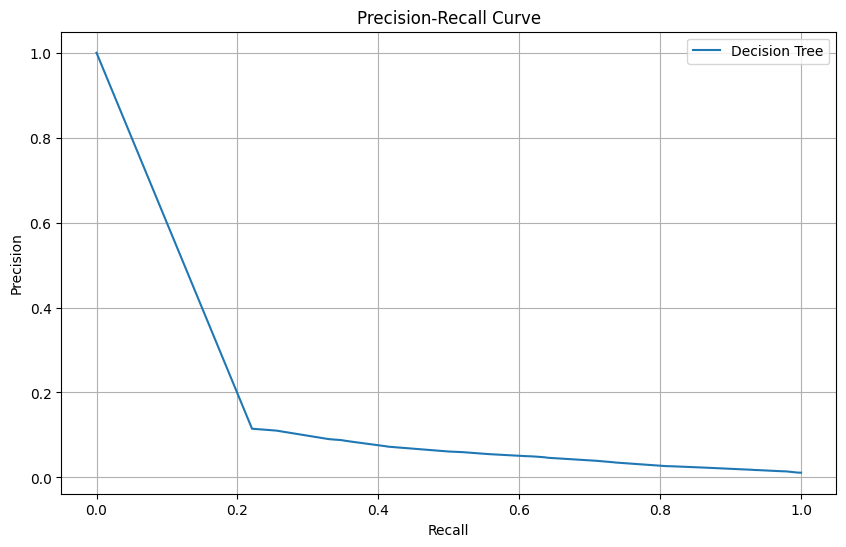

In [42]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall for all possible thresholds
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

# Plot Precision vs Recall
plt.figure(figsize=(10, 6))

plt.plot(
    recall,
    precision,
    label="Decision Tree"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()

plt.show()

In [43]:
threshold_analysis = []

for threshold in thresholds:

    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    tp = ((y_test == 1) & (y_pred_threshold == 1)).sum()
    fp = ((y_test == 0) & (y_pred_threshold == 1)).sum()
    fn = ((y_test == 1) & (y_pred_threshold == 0)).sum()

    threshold_analysis.append({
        "threshold": threshold,
        "true_positives": tp,
        "false_positives": fp,
        "fraud_missed": fn,
        "precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

threshold_analysis_df = pd.DataFrame(threshold_analysis)

# Show useful threshold range
display(
    threshold_analysis_df[
        threshold_analysis_df["threshold"].between(0.1, 0.9)
    ].round(4)
)

,threshold,true_positives,false_positives,fraud_missed,precision,recall,f1
3,0.1803,2159,150103,47,0.0142,0.9787,0.0280
4,0.2113,2140,143498,66,0.0147,0.9701,0.0289
5,0.2115,2070,117857,136,0.0173,0.9383,0.0339
6,0.2164,2067,117618,139,0.0173,0.9370,0.0339
7,0.2246,2058,114945,148,0.0176,0.9329,0.0345
8,0.2477,2050,111787,156,0.0180,0.9293,0.0353
9,0.3453,1929,84961,277,0.0222,0.8744,0.0433
10,0.3736,1924,84102,282,0.0224,0.8722,0.0436
11,0.3741,1898,79782,308,0.0232,0.8604,0.0453
12,0.3981,1804,67212,402,0.0261,0.8178,0.0507


In [44]:
from sklearn.model_selection import train_test_split

# Split the existing training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.1765,       # gives approximately 70/15/15 overall
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test_processed.shape)

print("\nFraud percentage:")
print("Training   :", y_train_final.mean() * 100)
print("Validation :", y_val.mean() * 100)
print("Test       :", y_test.mean() * 100)

Training set: (658800, 57)
Validation set: (141200, 57)
Test set: (200000, 57)

Fraud percentage:
Training   : 1.1029143897996359
Validation : 1.1026912181303117
Test       : 1.103


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Final candidate Decision Tree
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Train ONLY on training data
dt_model.fit(X_train_final, y_train_final)

# Predictions on validation set
y_val_pred = dt_model.predict(X_val)

# Validation performance
print("===== VALIDATION PERFORMANCE =====")

print("Precision:", precision_score(
    y_val, y_val_pred, zero_division=0
))

print("Recall   :", recall_score(
    y_val, y_val_pred, zero_division=0
))

print("F1 Score :", f1_score(
    y_val, y_val_pred, zero_division=0
))

===== VALIDATION PERFORMANCE =====
Precision: 0.03818532142231564
Recall   : 0.7000642260757868
F1 Score : 0.0724204371802538


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train_final, y_train_final)

# Validation predictions
y_val_pred_rf = rf_model.predict(X_val)

print("\n===== RANDOM FOREST VALIDATION =====")

print("Precision:", precision_score(
    y_val, y_val_pred_rf, zero_division=0
))

print("Recall   :", recall_score(
    y_val, y_val_pred_rf, zero_division=0
))

print("F1 Score :", f1_score(
    y_val, y_val_pred_rf, zero_division=0
))

Training Random Forest...

===== RANDOM FOREST VALIDATION =====
Precision: 0.040949100650593186
Recall   : 0.7559409120102761
F1 Score : 0.0776897689768977


In [47]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.1765,
    random_state=42,
    stratify=y_train
)

print("X_train_final:", X_train_final.shape)
print("X_val:", X_val.shape)
print("y_train_final:", y_train_final.shape)
print("y_val:", y_val.shape)

X_train_final: (658800, 57)
X_val: (141200, 57)
y_train_final: (658800,)
y_val: (141200,)


In [48]:
print(type(X_train_processed))
print(X_train_processed.shape)

<class 'numpy.ndarray'>
(800000, 57)


In [49]:
print([name for name in globals() if "encoder" in name.lower() or "preprocess" in name.lower() or "transform" in name.lower()])

['ColumnTransformer', 'OneHotEncoder', 'numeric_transformer', 'categorical_transformer', 'preprocessor']


In [50]:
# Show variables that might contain our preprocessing pipeline
[
    name for name in globals()
    if any(word in name.lower()
           for word in ["preprocessor", "preprocess", "encoder", "transformer", "ct"])
]

['ColumnTransformer',
 'OneHotEncoder',
 'numeric_transformer',
 'categorical_transformer',
 'preprocessor']

In [51]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 57
['num__income' 'num__name_email_similarity'
 'num__prev_address_months_count' 'num__current_address_months_count'
 'num__customer_age' 'num__days_since_request'
 'num__intended_balcon_amount' 'num__zip_count_4w' 'num__velocity_6h'
 'num__velocity_24h' 'num__velocity_4w' 'num__bank_branch_count_8w'
 'num__date_of_birth_distinct_emails_4w' 'num__credit_risk_score'
 'num__email_is_free' 'num__phone_home_valid' 'num__phone_mobile_valid'
 'num__bank_months_count' 'num__has_other_cards'
 'num__proposed_credit_limit' 'num__foreign_request'
 'num__session_length_in_minutes' 'num__keep_alive_session'
 'num__device_distinct_emails_8w' 'num__month'
 'num__prev_address_months_count_missing'
 'num__current_address_months_count_missing'
 'num__credit_risk_score_missing' 'num__bank_months_count_missing'
 'num__session_length_in_minutes_missing'
 'num__device_distinct_emails_8w_missing' 'cat__payment_type_AA'
 'cat__payment_type_AB' 'cat__payment_type_AC' 'cat__payment_type_AD'


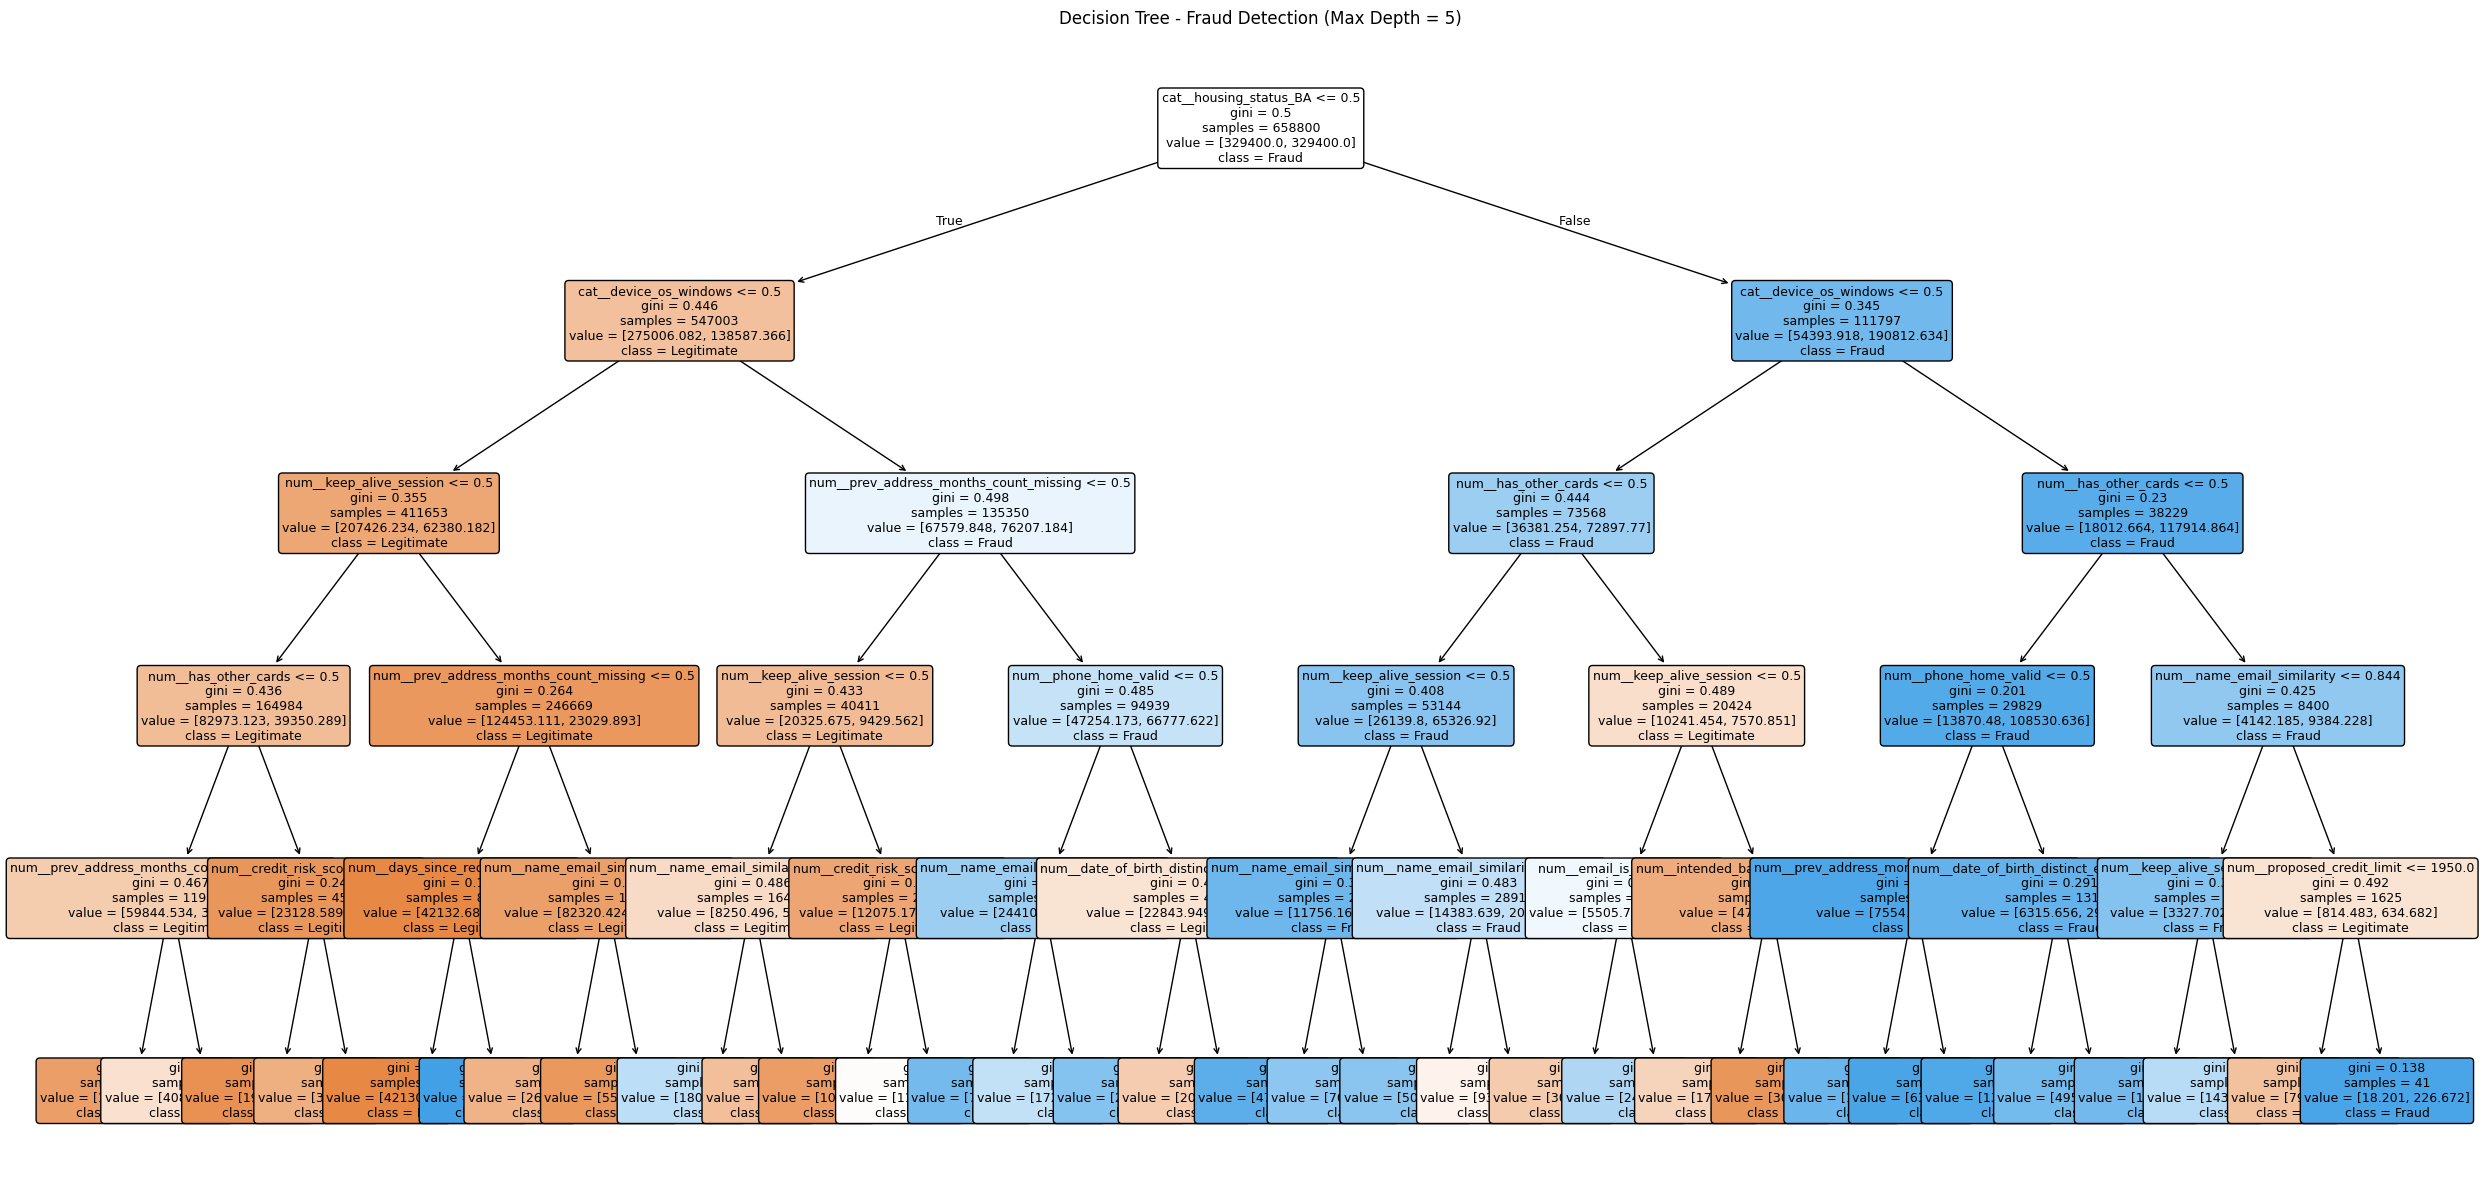

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["Legitimate", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - Fraud Detection (Max Depth = 5)")
plt.show()

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

leaf_values = [1, 2, 5, 10, 20, 50]

leaf_results = []

for leaf in leaf_values:

    print(f"Training min_samples_leaf = {leaf}...")

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=5,
        min_samples_leaf=leaf,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_final, y_train_final)

    y_val_pred = model.predict(X_val)

    leaf_results.append({
        "min_samples_leaf": leaf,
        "precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })

leaf_results_df = pd.DataFrame(leaf_results)

display(leaf_results_df)

Training min_samples_leaf = 1...
Training min_samples_leaf = 2...
Training min_samples_leaf = 5...
Training min_samples_leaf = 10...
Training min_samples_leaf = 20...
Training min_samples_leaf = 50...


,min_samples_leaf,precision,recall,f1
0,1,0.040949,0.755941,0.077690
1,2,0.040949,0.755941,0.077690
2,5,0.040949,0.755941,0.077690
3,10,0.040929,0.755299,0.077649
4,20,0.041060,0.756583,0.077892
5,50,0.041256,0.755941,0.078242


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

depths = list(range(5, 101, 10))

rf_depth_results = []

for depth in depths:

    print(f"Training Random Forest with max_depth = {depth}...")

    rf = RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        max_depth=depth,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_final, y_train_final)

    y_val_pred = rf.predict(X_val)

    rf_depth_results.append({
        "max_depth": depth,
        "precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })

rf_depth_results_df = pd.DataFrame(rf_depth_results)

display(rf_depth_results_df)

Training Random Forest with max_depth = 5...
Training Random Forest with max_depth = 15...
Training Random Forest with max_depth = 25...
Training Random Forest with max_depth = 35...
Training Random Forest with max_depth = 45...
Training Random Forest with max_depth = 55...
Training Random Forest with max_depth = 65...
Training Random Forest with max_depth = 75...
Training Random Forest with max_depth = 85...
Training Random Forest with max_depth = 95...


,max_depth,precision,recall,f1
0,5,0.041256,0.755941,0.078242
1,15,0.080933,0.541426,0.140817
2,25,0.098840,0.492614,0.164645
3,35,0.098150,0.490687,0.163580
4,45,0.098150,0.490687,0.163580
5,55,0.098150,0.490687,0.163580
6,65,0.098150,0.490687,0.163580
7,75,0.098150,0.490687,0.163580
8,85,0.098150,0.490687,0.163580
9,95,0.098150,0.490687,0.163580


In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# FINAL DECISION TREE
# ==========================================

dt_final = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Train
dt_final.fit(X_train_final, y_train_final)

# Validation predictions
y_val_pred_dt = dt_final.predict(X_val)

# ==========================================
# VALIDATION PERFORMANCE
# ==========================================

print("===== FINAL DECISION TREE =====")

print("Accuracy :", round(
    accuracy_score(y_val, y_val_pred_dt), 4
))

print("Precision:", round(
    precision_score(y_val, y_val_pred_dt, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_val, y_val_pred_dt, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_val, y_val_pred_dt, zero_division=0), 4
))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_val,
        y_val_pred_dt,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_val, y_val_pred_dt))

===== FINAL DECISION TREE =====
Accuracy : 0.8023
Precision: 0.0382
Recall   : 0.7001
F1 Score : 0.0724

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.80      0.89    139643
       Fraud       0.04      0.70      0.07      1557

    accuracy                           0.80    141200
   macro avg       0.52      0.75      0.48    141200
weighted avg       0.99      0.80      0.88    141200


===== CONFUSION MATRIX =====
[[112188  27455]
 [   467   1090]]


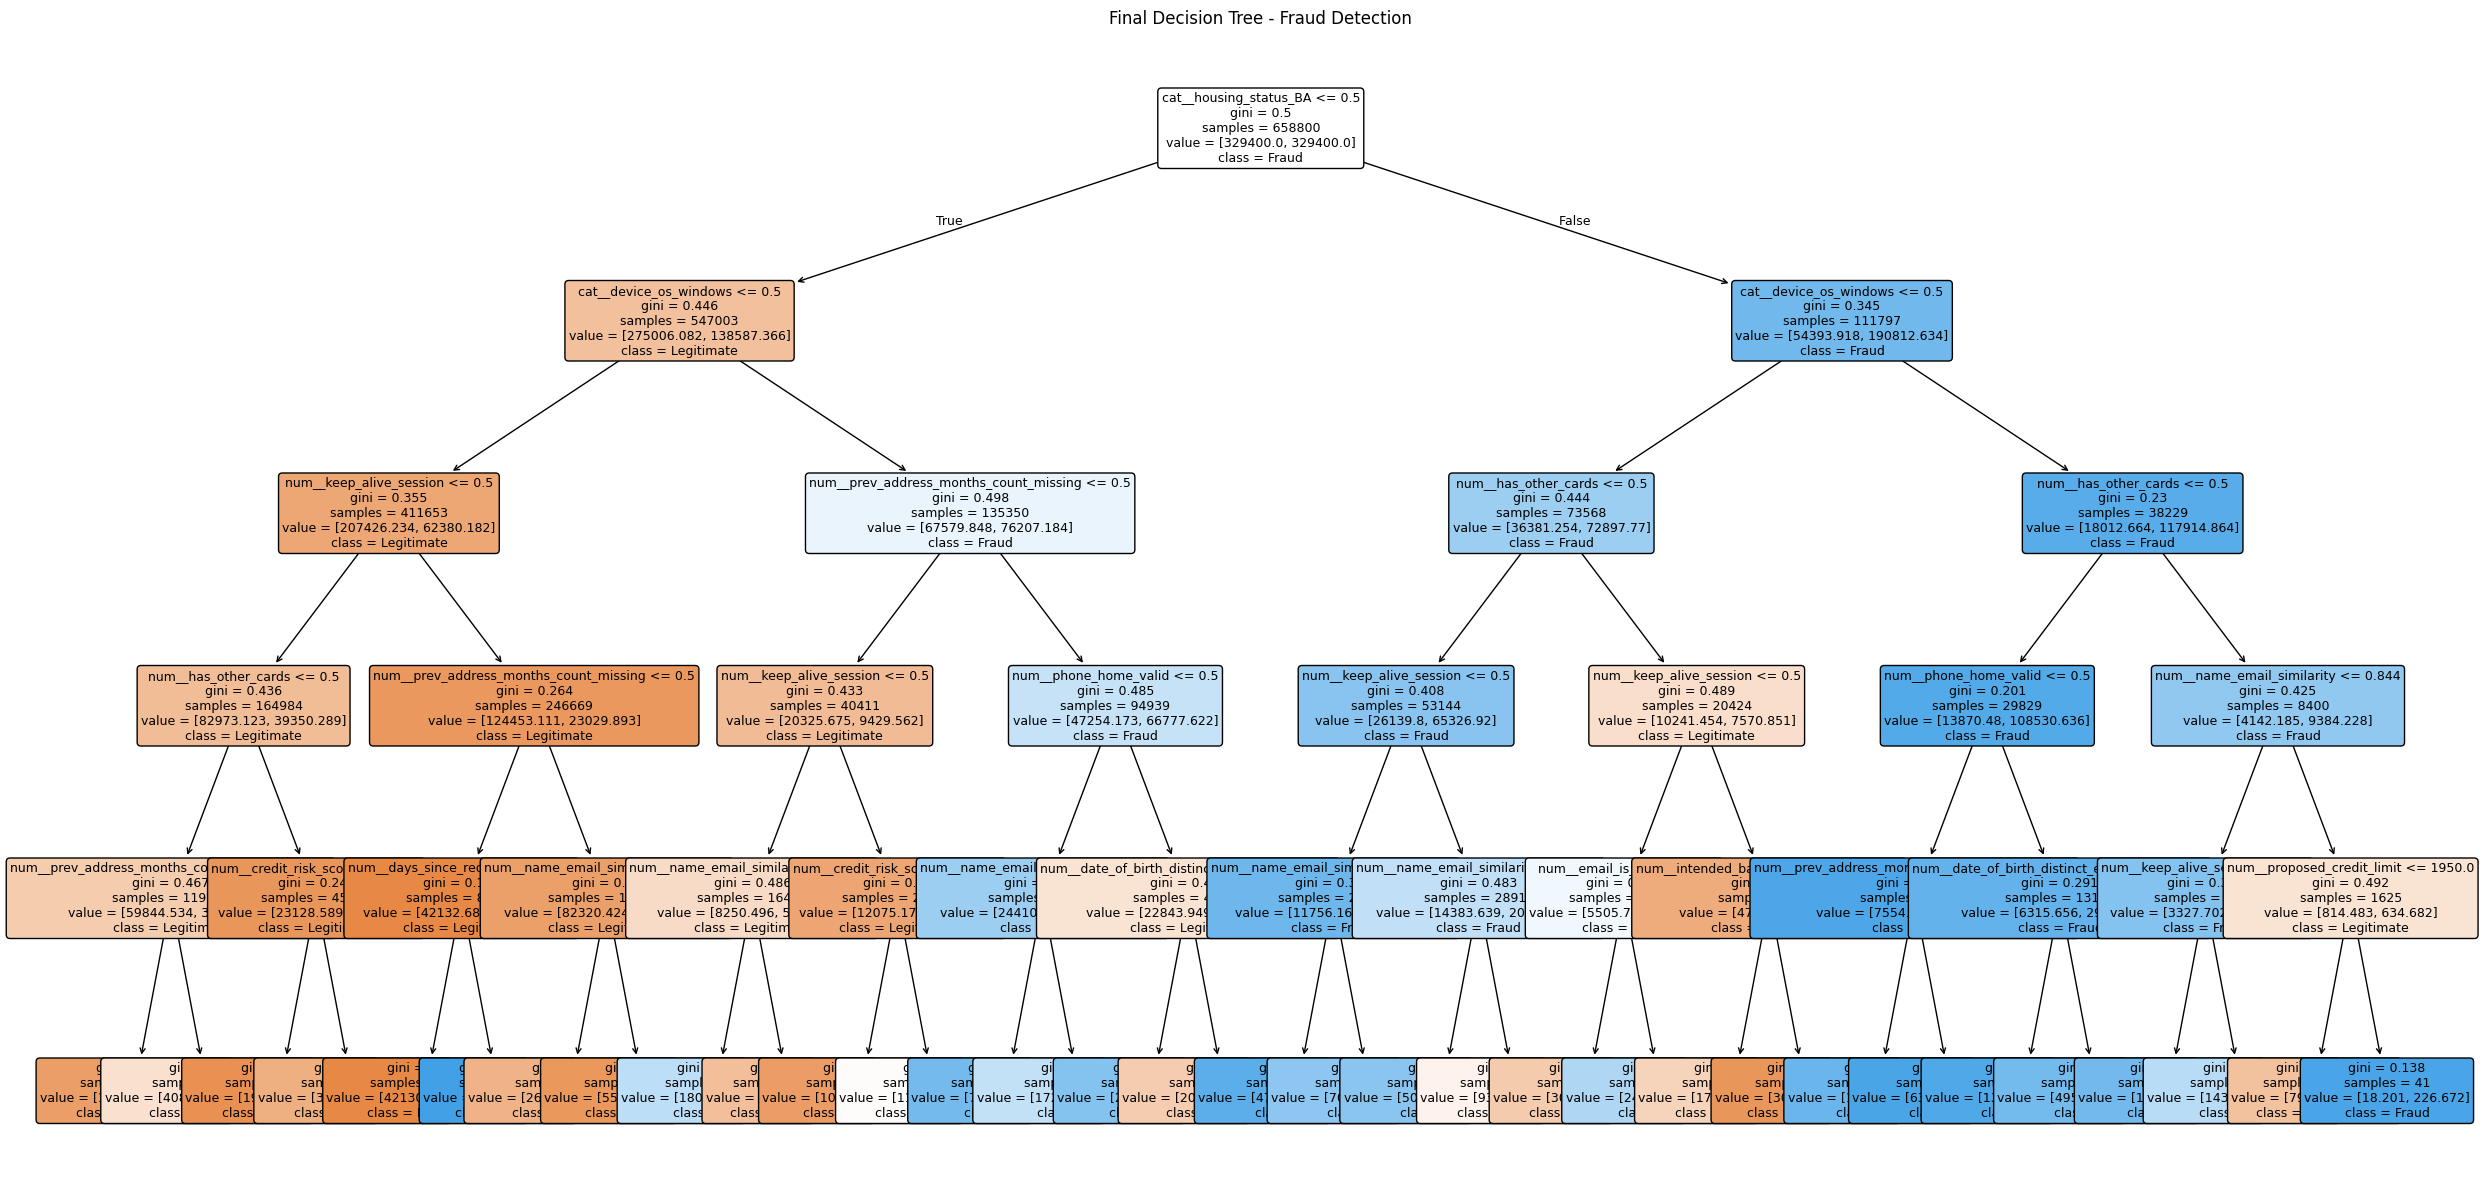

In [57]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 15))

plot_tree(
    dt_final,
    feature_names=feature_names,
    class_names=["Legitimate", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Final Decision Tree - Fraud Detection")
plt.show()

In [63]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ==========================================
# LINEAR REGRESSION
# ==========================================

lr_model = LinearRegression()

# Train
lr_model.fit(X_train_final, y_train_final)

# Predict
y_test_pred_lr = lr_model.predict(X_test_processed)

# ==========================================
# EVALUATION
# ==========================================

mae = mean_absolute_error(y_test, y_test_pred_lr)
mse = mean_squared_error(y_test, y_test_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred_lr)

print("===== LINEAR REGRESSION — TEST SET =====")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

===== LINEAR REGRESSION — TEST SET =====
MAE  : 0.0265
MSE  : 0.0105
RMSE : 0.1027
R²   : 0.0340


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# FINAL DECISION TREE — TEST SET
# ==========================================

y_test_pred_dt = dt_final.predict(X_test_processed)

print("===== FINAL DECISION TREE — TEST SET =====")

print("Accuracy :", round(
    accuracy_score(y_test, y_test_pred_dt), 4
))

print("Precision:", round(
    precision_score(y_test, y_test_pred_dt, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test, y_test_pred_dt, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_test_pred_dt, zero_division=0), 4
))

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_test_pred_dt,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

print("\n===== CONFUSION MATRIX =====")

print(confusion_matrix(y_test, y_test_pred_dt))

===== FINAL DECISION TREE — TEST SET =====
Accuracy : 0.8037
Precision: 0.0389
Recall   : 0.709
F1 Score : 0.0738

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Legitimate       1.00      0.80      0.89    197794
       Fraud       0.04      0.71      0.07      2206

    accuracy                           0.80    200000
   macro avg       0.52      0.76      0.48    200000
weighted avg       0.99      0.80      0.88    200000


===== CONFUSION MATRIX =====
[[159185  38609]
 [   642   1564]]


In [60]:
from sklearn.ensemble import RandomForestClassifier

# FINAL RANDOM FOREST CANDIDATE
rf_best = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=25,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training final Random Forest...")

rf_best.fit(X_train_final, y_train_final)

# Fraud probability on validation set
y_val_proba_rf = rf_best.predict_proba(X_val)[:, 1]

print("Done!")
print("Validation probabilities generated:", len(y_val_proba_rf))

Training final Random Forest...
Done!
Validation probabilities generated: 141200


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Final Random Forest prediction
y_test_pred_rf = rf_best.predict(X_test_processed)

print("===== FINAL RANDOM FOREST — TEST SET =====")

print("Accuracy :", round(
    accuracy_score(y_test, y_test_pred_rf), 4
))

print("Precision:", round(
    precision_score(y_test, y_test_pred_rf, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test, y_test_pred_rf, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_test_pred_rf, zero_division=0), 4
))

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_test_pred_rf,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

print("\n===== CONFUSION MATRIX =====")

print(confusion_matrix(y_test, y_test_pred_rf))

===== FINAL RANDOM FOREST — TEST SET =====
Accuracy : 0.9458
Precision: 0.1055
Recall   : 0.5231
F1 Score : 0.1756

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  Legitimate       0.99      0.95      0.97    197794
       Fraud       0.11      0.52      0.18      2206

    accuracy                           0.95    200000
   macro avg       0.55      0.74      0.57    200000
weighted avg       0.98      0.95      0.96    200000


===== CONFUSION MATRIX =====
[[188013   9781]
 [  1052   1154]]


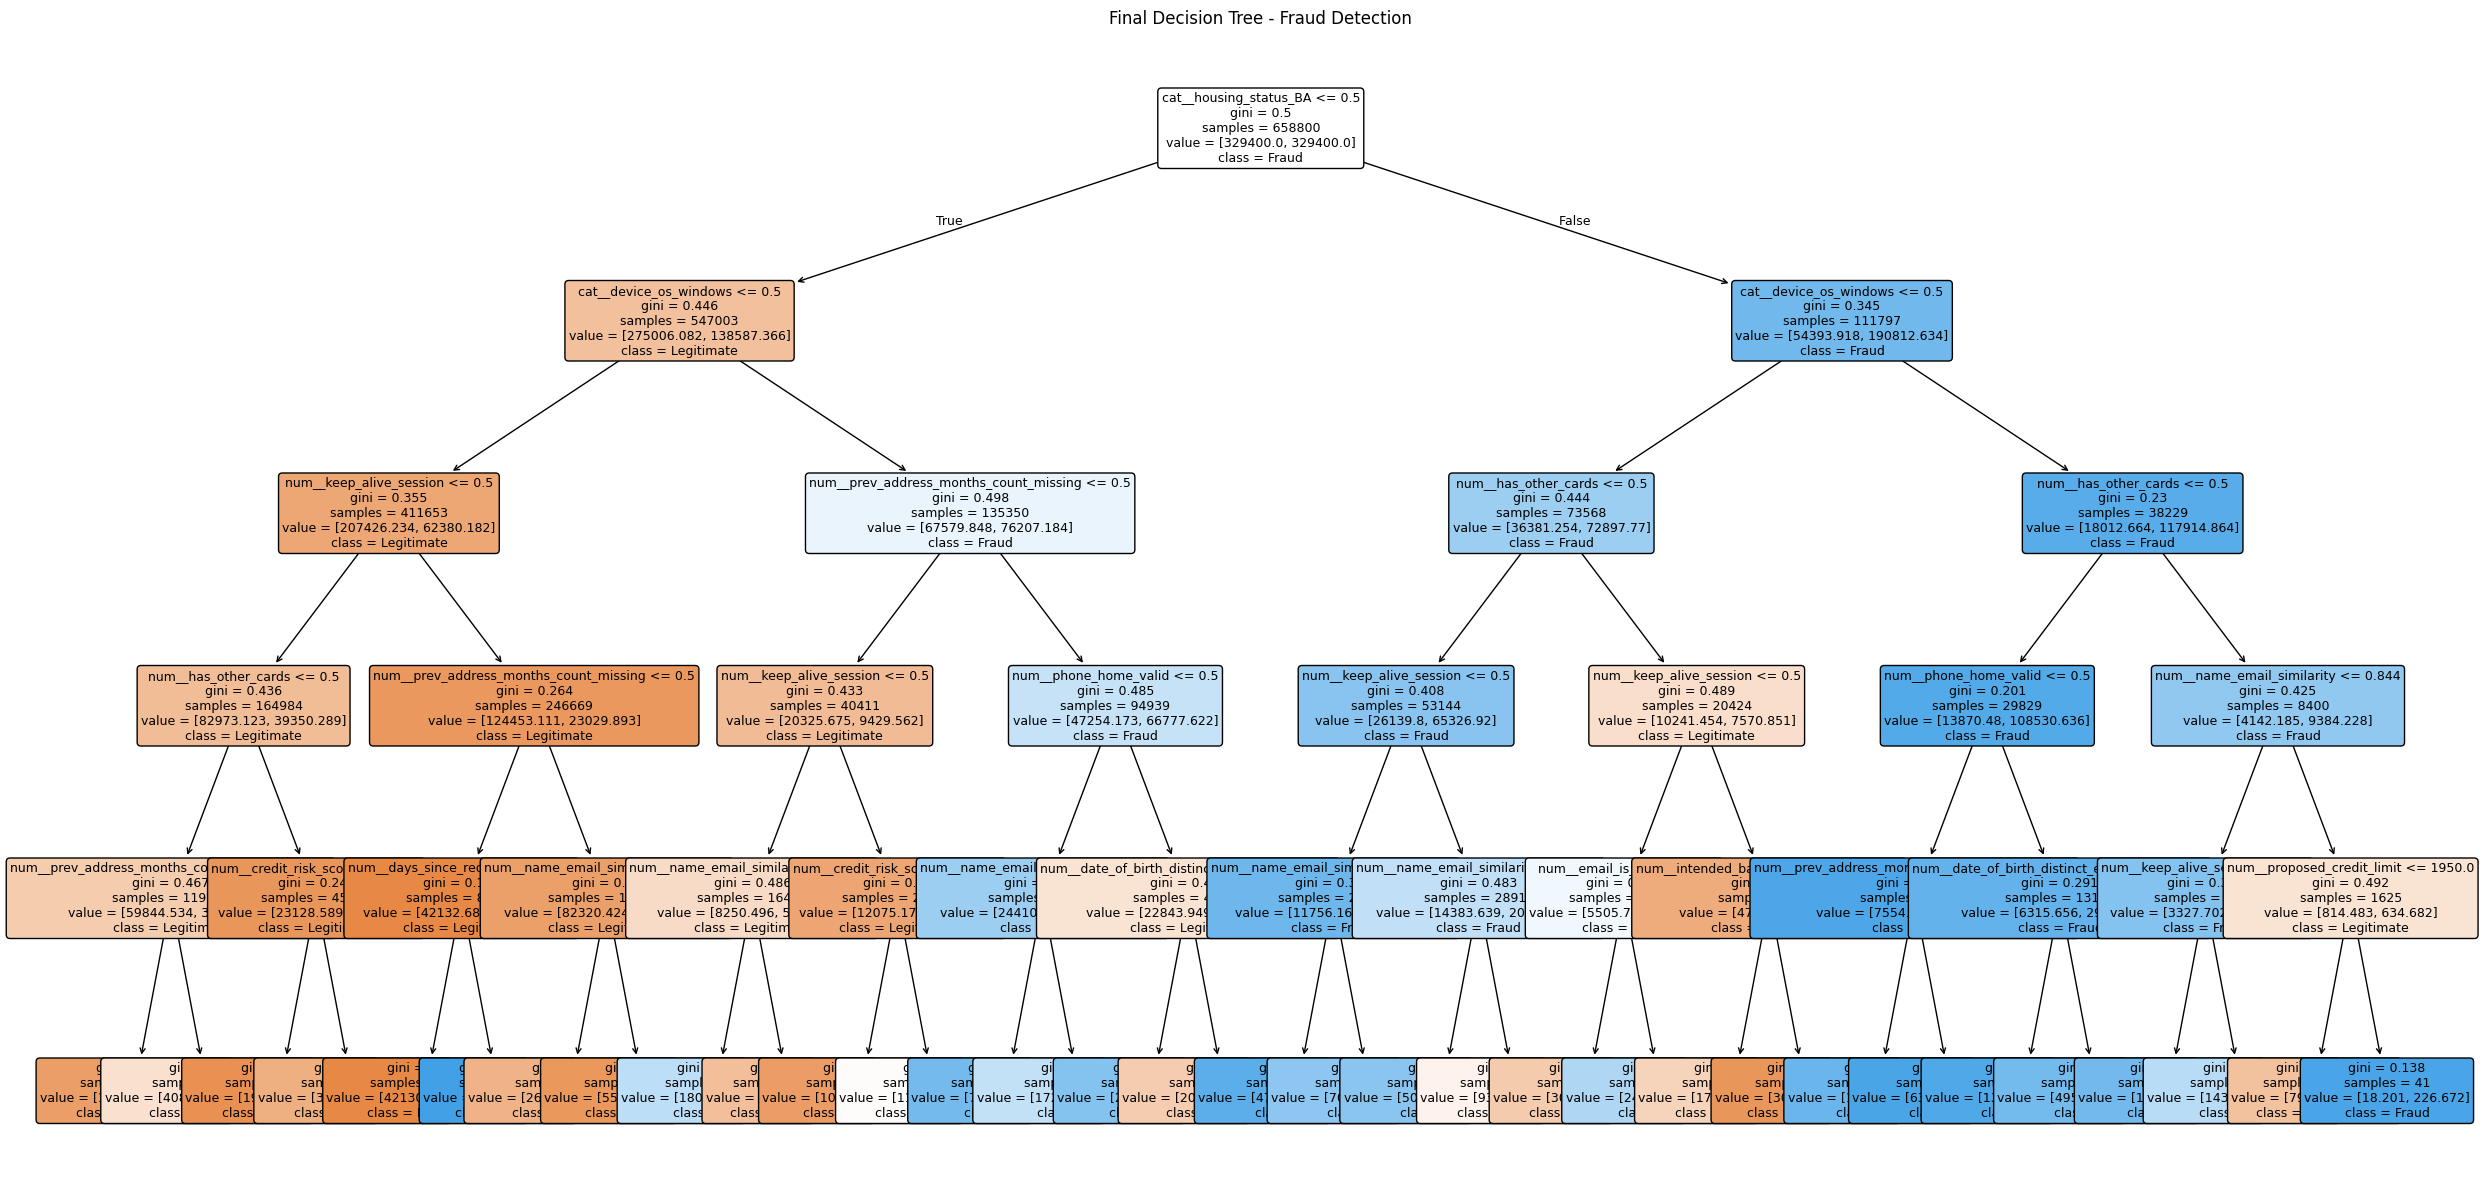

In [62]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 15))

plot_tree(
    dt_final,
    feature_names=feature_names,
    class_names=["Legitimate", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Final Decision Tree - Fraud Detection")
plt.show()